# Linear / Ridge Regression + Categorical Preprocessor (scikit-learn)

This notebook builds a **reusable preprocessing handler** for linear models (and most classical ML models):
- Categorical features → `OneHotEncoder(handle_unknown='ignore')`
- Numeric features → impute + scale
- Export the fitted preprocessor with `joblib` into `ml-service/models/preprocessors/`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, MaxNLocator
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import seaborn as sns
import joblib

def find_ml_root_for_import(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'app' / 'core' / 'config.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate ml-service root containing app/core/config.py')

ML_ROOT = find_ml_root_for_import()
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))


plt.style.use("seaborn-v0_8-dark")


from app.core.config import settings

## 1) Load Data

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

TARGET_COL = 'price_egp'  # you can switch to 'price_egp_log' for a more linear-friendly target
DROP_COLS = {'price_egp', 'price_egp_log'}

df = settings.load_data('processed').copy()

# Clean basic string columns
for col in ['make', 'model', 'transmission', 'fuel', 'location', 'body_type', 'drivetrain', 'brand_origin', 'car_segment']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

assert TARGET_COL in df.columns, f'Missing target column: {TARGET_COL}'

feature_cols = [c for c in df.columns if c not in DROP_COLS]
X_all = df[feature_cols].copy()
y_all = df[TARGET_COL].copy()

print('Rows:', len(df))
print('Features:', len(feature_cols))
print('Target:', TARGET_COL)
X_all.head()

Rows: 20461
Features: 16
Target: price_egp


,make,model,year,car_age,transmission,fuel,mileage_km,mileage_per_year,location,engine_cc,horsepower,body_type,drivetrain,seating_capacity,brand_origin,car_segment
0,BYD,F3,2024.0,2.0,Manual,petrol,4410.0,2205.000000,Cairo,1500,109,Sedan,FWD,5,chinese,family
1,BYD,F3,2025.0,1.0,Manual,petrol,33033.0,33033.000000,Nasr City,1500,109,Sedan,FWD,5,chinese,family
2,Subaru,Impreza,2009.0,17.0,Manual,petrol,98000.0,5764.705882,Maadi,1498,107,Sedan,AWD,5,japanese,family
3,BYD,F3,2024.0,2.0,Manual,petrol,78642.0,39321.000000,Cairo,1500,109,Sedan,FWD,5,chinese,family
4,Peugeot,206,2002.0,24.0,Manual,petrol,200000.0,8333.333333,Alexandria,1400,75,Hatchback,FWD,5,european,city


## 1.1) Quick Sanity Checks
Small checks to confirm dtypes, missing values, and basic target stats before modeling.

In [3]:
df.head()

,make,model,year,car_age,transmission,fuel,mileage_km,mileage_per_year,location,engine_cc,horsepower,body_type,drivetrain,seating_capacity,brand_origin,car_segment,price_egp,price_egp_log
0,BYD,F3,2024.0,2.0,Manual,petrol,4410.0,2205.000000,Cairo,1500,109,Sedan,FWD,5,chinese,family,630000,13.353475
1,BYD,F3,2025.0,1.0,Manual,petrol,33033.0,33033.000000,Nasr City,1500,109,Sedan,FWD,5,chinese,family,610000,13.321214
2,Subaru,Impreza,2009.0,17.0,Manual,petrol,98000.0,5764.705882,Maadi,1498,107,Sedan,AWD,5,japanese,family,410000,12.923912
3,BYD,F3,2024.0,2.0,Manual,petrol,78642.0,39321.000000,Cairo,1500,109,Sedan,FWD,5,chinese,family,570000,13.253392
4,Peugeot,206,2002.0,24.0,Manual,petrol,200000.0,8333.333333,Alexandria,1400,75,Hatchback,FWD,5,european,city,230000,12.345835


In [4]:
df.dtypes.to_frame('dtype')

,dtype
make,str
model,str
year,float64
car_age,float64
transmission,str
fuel,str
mileage_km,float64
mileage_per_year,float64
location,str
engine_cc,int64


In [6]:
df[TARGET_COL].describe().to_frame('value')

,value
count,2.046100e+04
mean,1.084854e+06
std,1.466518e+06
min,2.222200e+04
25%,3.300000e+05
50%,6.250000e+05
75%,1.200000e+06
max,2.000000e+07


## 2) Split Strategies (5 ways)
We will evaluate:
- **A) Random train/test split (rows)**
- **B) 80/20 within each (make, model)** (rows held out, same make+model exists in train)
- **C) Split by make only** (hold out entire makes; hardest)
- **D) Random stratified split by `make`** (keeps brand distribution similar in train/test)
- **E) Random stratified split by **price range bins** (keeps target distribution similar in train/test)

In [7]:
rng = np.random.default_rng(RANDOM_STATE)

def split_random_rows(X: pd.DataFrame, y: pd.Series):
    return train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

def split_stratified_by_make(df_full: pd.DataFrame, feature_cols: list[str], target_col: str):
    """Random split stratified by make to preserve brand ratios.

    Note: sklearn stratification requires each class to have >= 2 samples overall.
    We collapse extremely rare makes into 'RARE_MAKE' for stability.
    """
    make_counts = df_full["make"].value_counts()
    strat_col = df_full["make"].where(df_full["make"].map(make_counts) >= 2, "RARE_MAKE")

    idx = df_full.index.to_numpy()
    train_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strat_col
    )
    train_df = df_full.loc[train_idx]
    test_df = df_full.loc[test_idx]
    return (
        train_df[feature_cols],
        test_df[feature_cols],
        train_df[target_col],
        test_df[target_col],
)

def _build_strat_bins_from_price(price: pd.Series, desired_bins: int = 10) -> pd.Series:
    """Create robust stratification labels from a continuous price series.

    Uses quantile bins (qcut) and collapses rare bins (<2 rows) into a single 'RARE_BIN'.
    If qcut fails due to duplicates, it automatically reduces bin count.
    """
    s = pd.to_numeric(price, errors="coerce")
    s = s.fillna(s.median())

    # Try several bin counts to find something stratify-safe.
    for q in [desired_bins, 8, 6, 5, 4, 3]:
        try:
            b = pd.qcut(s, q=q, duplicates="drop")
        except Exception:
            continue

        # Use category codes (stable + compact) then collapse very small bins.
        codes = b.cat.codes.astype(int)
        counts = codes.value_counts()
        rare_codes = counts[counts < 2].index
        if len(rare_codes) > 0:
            codes = codes.where(~codes.isin(rare_codes), -1)
        # After collapsing, ensure all bins have >=2 samples
        if codes.value_counts().min() >= 2:
            return codes

    # Fallback: single bin (no stratification benefit, but avoids hard failure).
    return pd.Series(np.zeros(len(s), dtype=int), index=price.index)

def split_stratified_by_price_bins(
    df_full: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    price_col_for_bins: str = "price_egp",
    desired_bins: int = 10,
):
    """Random split stratified by price-range bins.

    Stratification is based on `price_col_for_bins` (usually raw `price_egp`) even if the
    modeling target is `price_egp_log`.
    """
    if price_col_for_bins not in df_full.columns:
        price_col_for_bins = target_col  # fallback if raw price not present
    strat_bins = _build_strat_bins_from_price(df_full[price_col_for_bins], desired_bins=desired_bins)

    idx = df_full.index.to_numpy()
    train_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strat_bins
    )
    train_df = df_full.loc[train_idx]
    test_df = df_full.loc[test_idx]
    return (
        train_df[feature_cols],
        test_df[feature_cols],
        train_df[target_col],
        test_df[target_col],
)

def split_within_make_model_rows(df_full: pd.DataFrame):
    """Hold out ~20% rows within each (make, model).
    This matches the use-case: new listings for an already-known make+model.
    """
    min_rows_per_group = 5
    force_at_least_one_test_row = True

    train_idx: list[int] = []
    test_idx: list[int] = []

    for (_, _), gdf in df_full.groupby(["make", "model"], sort=False):
        n = len(gdf)
        if n < min_rows_per_group:
            train_idx.extend(gdf.index.to_list())
            continue

        n_test = int(np.floor(TEST_SIZE * n))
        if force_at_least_one_test_row:
            n_test = max(1, n_test)
        n_test = min(n_test, n - 1)  # keep at least one row in train
        chosen = rng.choice(gdf.index.to_numpy(), size=n_test, replace=False)
        chosen_set = set(chosen.tolist())

        test_idx.extend(list(chosen_set))
        train_idx.extend([i for i in gdf.index.to_list() if i not in chosen_set])

    train_df = df_full.loc[train_idx]
    test_df = df_full.loc[test_idx]

    assert set(train_idx).isdisjoint(set(test_idx))
    assert set(test_df["make"]).issubset(set(train_df["make"]))
    return train_df, test_df

def split_by_make_only(df_full: pd.DataFrame):
    """Hold out entire makes. Hardest split: test contains makes unseen during training."""
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    groups = df_full["make"]
    train_idx, test_idx = next(splitter.split(df_full, groups=groups))
    train_df = df_full.iloc[train_idx]
    test_df = df_full.iloc[test_idx]

    assert set(test_df["make"]).isdisjoint(set(train_df["make"]))
    return train_df, test_df

# We'll build the splits dictionary in separate cells for clarity
splits: dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]] = {}

### A) Random rows split

In [8]:
X_tr, X_te, y_tr, y_te = split_random_rows(X_all, y_all)
splits["A_random_rows"] = (X_tr, X_te, y_tr, y_te)
print("A_random_rows", "| train:", len(X_tr), " test:", len(X_te))

A_random_rows | train: 16368  test: 4093


### B) 80/20 within each (make, model) (row holdout)

In [9]:
train_df, test_df = split_within_make_model_rows(df)

X_tr = train_df[feature_cols]
X_te = test_df[feature_cols]
y_tr = train_df[TARGET_COL]
y_te = test_df[TARGET_COL]

splits["B_within_make_model_rows"] = (X_tr, X_te, y_tr, y_te)
print("B_within_make_model_rows", "| train:", len(X_tr), " test:", len(X_te))

B_within_make_model_rows | train: 16560  test: 3901


### C) Split by make only (hold out brands)

In [10]:
train_df, test_df = split_by_make_only(df)

X_tr = train_df[feature_cols]
X_te = test_df[feature_cols]
y_tr = train_df[TARGET_COL]
y_te = test_df[TARGET_COL]

splits["C_split_by_make_only"] = (X_tr, X_te, y_tr, y_te)
print("C_split_by_make_only", "| train:", len(X_tr), " test:", len(X_te))
print("Held-out makes (test):", test_df['make'].nunique())

C_split_by_make_only | train: 15298  test: 5163
Held-out makes (test): 15


### D) Random stratified split by make (keeps brand ratios)

In [11]:
X_tr, X_te, y_tr, y_te = split_stratified_by_make(df, feature_cols=feature_cols, target_col=TARGET_COL)
splits["D_stratified_by_make"] = (X_tr, X_te, y_tr, y_te)
print("D_stratified_by_make", "| train:", len(X_tr), " test:", len(X_te))

# Quick check: compare make distribution (train vs test)
train_make = X_tr['make'].value_counts(normalize=True).rename('train')
test_make = X_te['make'].value_counts(normalize=True).rename('test')
train_make.to_frame().join(test_make.to_frame(), how='outer').fillna(0.0).head(10)

D_stratified_by_make | train: 16368  test: 4093


,train,test
make,,
Alfa Romeo,0.000367,0.000489
Audi,0.009103,0.009040
Avatr,0.001527,0.001466
BAIC,0.003177,0.003176
BMW,0.044844,0.044955
BYD,0.011975,0.011972
Brilliance,0.004765,0.004642
Cadillac,0.000489,0.000489
Chana,0.000305,0.000244


### E) Random stratified split by price range (bins)

In [12]:
X_tr, X_te, y_tr, y_te = split_stratified_by_price_bins(
    df,
    feature_cols=feature_cols,
    target_col=TARGET_COL,
    price_col_for_bins='price_egp',
    desired_bins=10,
)
splits["E_stratified_by_price_range"] = (X_tr, X_te, y_tr, y_te)

print("E_stratified_by_price_range", "| train:", len(X_tr), " test:", len(X_te))

# Quick check: stratification bin counts (after rare-bin collapsing)
bins = _build_strat_bins_from_price(df['price_egp'], desired_bins=10) if 'price_egp' in df.columns else _build_strat_bins_from_price(df[TARGET_COL], desired_bins=10)
bins.value_counts().head(10)

E_stratified_by_price_range | train: 16368  test: 4093


2    2166
0    2163
6    2102
5    2060
7    2039
4    2036
9    2023
8    1995
3    1942
1    1935
Name: count, dtype: int64

In [13]:
# Build split indices once so we can benchmark multiple targets fairly
# (same train/test rows, different y).
split_indices: dict[str, tuple[np.ndarray, np.ndarray]] = {
    name: (Xtr.index.to_numpy(), Xte.index.to_numpy())
    for name, (Xtr, Xte, _ytr, _yte) in splits.items()
}

print('Split index sets ready:', list(split_indices.keys()))
print('Example sizes:', {k: (len(v[0]), len(v[1])) for k, v in list(split_indices.items())[:2]})

Split index sets ready: ['A_random_rows', 'B_within_make_model_rows', 'C_split_by_make_only', 'D_stratified_by_make', 'E_stratified_by_price_range']
Example sizes: {'A_random_rows': (16368, 4093), 'B_within_make_model_rows': (16560, 3901)}


## 3) Preprocessor + Models
We auto-detect categorical vs numeric columns:
- Categorical: `object` / `category` → `OneHotEncoder(handle_unknown='ignore')`
- Numeric: everything else → `SimpleImputer(median)` + `StandardScaler`

Then we compare **LinearRegression** vs **Ridge** (often more stable with many one-hot features).

In [14]:
categorical_cols = X_all.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = [c for c in X_all.columns if c not in categorical_cols]

print("Categorical cols (one-hot):", categorical_cols)
print("Numeric cols (scale):", numeric_cols)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge(alpha=1.0)": Ridge(alpha=1.0),
}

Categorical cols (one-hot): ['make', 'model', 'transmission', 'fuel', 'location', 'body_type', 'drivetrain', 'brand_origin', 'car_segment']
Numeric cols (scale): ['year', 'car_age', 'mileage_km', 'mileage_per_year', 'engine_cc', 'horsepower', 'seating_capacity']


## 4) Metrics + Evaluation
We’ll fit a full pipeline: `preprocessor → model`, then evaluate on each split.

In [15]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))

    # MAPE: robust to zeros
    eps = 1e-9
    denom = np.maximum(np.abs(y_true), eps)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

    r2 = float(r2_score(y_true, y_pred))
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE_%": mape, "R2": r2}


In [16]:
# Display formatting: avoid scientific notation, keep <=3 decimals
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
np.set_printoptions(suppress=True)

### Cross-validation + hyperparameter tuning
We tune **Ridge** regularization strength (`alpha`) using CV on the training split only.

In [17]:
# CV config (used for Ridge tuning)
CV_FOLDS = 5
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

RIDGE_ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

from sklearn.metrics import make_scorer

def infer_log_kind(y_log: pd.Series) -> str:
    """Infer whether the log target is log10 or natural log by scale."""
    s = pd.to_numeric(y_log, errors="coerce")
    med = float(s.median())
    # Typical EGP prices: ~1e5..1e7, so log10 is ~5..7, ln is ~12..16
    return "ln" if med > 10.0 else "log10"

def log_to_price(y_log: np.ndarray | pd.Series, kind: str) -> np.ndarray:
    a = np.asarray(y_log, dtype=float)
    if kind == "ln":
        return np.exp(a)
    # default: log10
    return np.power(10.0, a)

def make_mae_price_scorer_from_log(kind: str):
    """MAE scorer in EGP when the model predicts log(price)."""
    def mae_price(y_true_log, y_pred_log):
        y_true = log_to_price(y_true_log, kind)
        y_pred = log_to_price(y_pred_log, kind)
        return mean_absolute_error(y_true, y_pred)
    return make_scorer(mae_price, greater_is_better=False)

def tune_ridge_pipeline(Xtr: pd.DataFrame, ytr: pd.Series, *, y_is_log: bool = False, log_kind: str | None = None):
    """Tune Ridge(alpha) using CV on the training set only.

    If `y_is_log=True`, CV and selection are done using MAE in **EGP** (after back-transform).
    """
    ridge = Ridge()
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", ridge)])

    if y_is_log:
        kind = log_kind or infer_log_kind(ytr)
        scoring = make_mae_price_scorer_from_log(kind)
    else:
        kind = None
        scoring = "neg_mean_absolute_error"

    grid = GridSearchCV(
        estimator=pipe,
        param_grid={"model__alpha": RIDGE_ALPHA_GRID},
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(Xtr, ytr)

    cv_results = pd.DataFrame(grid.cv_results_)
    # best_score_ is negative MAE for both configurations (sklearn convention)
    best_cv_mae = float(-grid.best_score_)
    return grid.best_estimator_, grid.best_params_, best_cv_mae, cv_results, kind

In [18]:
# We'll benchmark multiple targets using the SAME split indices (fair comparison)
TARGETS_TO_BENCH = [c for c in ["price_egp", "price_egp_log"] if c in df.columns]
print("Targets to benchmark:", TARGETS_TO_BENCH)

results_by_target: dict[str, pd.DataFrame] = {}
pred_store_by_target: dict[str, dict[str, dict]] = {}

print("Ready. Next cells will benchmark all splits for each target.")

Targets to benchmark: ['price_egp', 'price_egp_log']
Ready. Next cells will benchmark all splits for each target.


In [19]:
def compute_metrics_in_egp(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    *,
    y_is_log: bool,
    log_kind: str | None,
    ):
    """Return MAE/RMSE/MAPE/R2 in EGP for both raw-price and log-price targets."""
    if not y_is_log:
        y_true_arr = np.asarray(y_true, dtype=float)
        y_pred_arr = np.asarray(y_pred, dtype=float)
        return compute_metrics(y_true_arr, y_pred_arr), y_true_arr, y_pred_arr

    assert log_kind is not None, "log_kind is required when y_is_log=True"
    y_true_egp = log_to_price(y_true, log_kind)
    y_pred_egp = log_to_price(y_pred, log_kind)
    return compute_metrics(y_true_egp, y_pred_egp), y_true_egp, y_pred_egp

def fit_and_eval_linear(
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    Xte: pd.DataFrame,
    yte: pd.Series,
    *,
    y_is_log: bool,
    log_kind: str | None,
    ):
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", LinearRegression())])
    pipe.fit(Xtr, ytr)
    preds = pipe.predict(Xte)
    metrics, y_true_eval, y_pred_eval = compute_metrics_in_egp(
        yte, preds, y_is_log=y_is_log, log_kind=log_kind
    )
    return pipe, preds, metrics, y_true_eval, y_pred_eval

def fit_and_eval_ridge_tuned(
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    Xte: pd.DataFrame,
    yte: pd.Series,
    *,
    y_is_log: bool,
    log_kind: str | None,
    ):
    best_pipe, best_params, best_cv_mae, cv_results, inferred_kind = tune_ridge_pipeline(
        Xtr, ytr, y_is_log=y_is_log, log_kind=log_kind
    )
    kind = inferred_kind if y_is_log else None
    preds = best_pipe.predict(Xte)
    metrics, y_true_eval, y_pred_eval = compute_metrics_in_egp(
        yte, preds, y_is_log=y_is_log, log_kind=kind
    )
    return best_pipe, preds, metrics, best_params, best_cv_mae, cv_results, kind

def fit_and_eval_huber(
    Xtr: pd.DataFrame,
    ytr: pd.Series,
    Xte: pd.DataFrame,
    yte: pd.Series,
    *,
    y_is_log: bool,
    log_kind: str | None,
    epsilon: float = 1.35,
    alpha: float = 0.0001,
    max_iter: int = 1000,
    ):
    """HuberRegressor trial (Huber loss; more robust to outliers).

    Note: HuberRegressor requires dense input; we convert the sparse one-hot output to dense.
    """
    import warnings
    from sklearn.exceptions import ConvergenceWarning

    to_dense = FunctionTransformer(
        lambda x: x.toarray() if hasattr(x, "toarray") else x,
        accept_sparse=True,
    )
    huber = HuberRegressor(epsilon=epsilon, alpha=alpha, max_iter=max_iter)
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("to_dense", to_dense), ("model", huber)])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=ConvergenceWarning)
        pipe.fit(Xtr, ytr)

    preds = pipe.predict(Xte)
    metrics, y_true_eval, y_pred_eval = compute_metrics_in_egp(
        yte, preds, y_is_log=y_is_log, log_kind=log_kind
    )
    return pipe, preds, metrics, y_true_eval, y_pred_eval

## 4.1) Run models per split (small cells)
Each split below fits:
- **LinearRegression** (no tuning)
- **Ridge** with **CV tuning** for `alpha`

In [20]:
def build_splits_for_target(target_col: str):
    assert target_col in df.columns, f"Missing target column: {target_col}"
    splits_t: dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]] = {}
    for name, (tr_idx, te_idx) in split_indices.items():
        Xtr = df.loc[tr_idx, feature_cols]
        Xte = df.loc[te_idx, feature_cols]
        ytr = df.loc[tr_idx, target_col]
        yte = df.loc[te_idx, target_col]
        splits_t[name] = (Xtr, Xte, ytr, yte)
    return splits_t

def run_split(
    split_key: str,
    splits_dict: dict[str, tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]],
    *,
    train_target: str,
    y_is_log: bool,
    log_kind: str | None,
    rows_out: list[dict],
    pred_store_out: dict[str, dict],
):
    Xtr, Xte, ytr, yte = splits_dict[split_key]

    # LinearRegression
    lin_pipe, lin_preds_raw, lin_m, y_true_eval, lin_pred_eval = fit_and_eval_linear(
        Xtr, ytr, Xte, yte, y_is_log=y_is_log, log_kind=log_kind
    )
    rows_out.append({"split": split_key, "model": "LinearRegression", **lin_m})

    # Ridge (tuned)
    ridge_pipe, ridge_preds_raw, ridge_m, ridge_params, ridge_cv_mae, ridge_cv_results, used_kind = fit_and_eval_ridge_tuned(
        Xtr, ytr, Xte, yte, y_is_log=y_is_log, log_kind=log_kind
    )
    ridge_pred_eval = compute_metrics_in_egp(
        yte, ridge_preds_raw, y_is_log=y_is_log, log_kind=used_kind
    )[2]
    rows_out.append({
        "split": split_key,
        "model": "Ridge(tuned)",
        "best_alpha": float(ridge_params["model__alpha"]),
        "cv_MAE": float(ridge_cv_mae),
        **ridge_m,
    })

    # HuberRegressor (Huber loss)
    huber_pipe, huber_preds_raw, huber_m, _y_true_eval2, huber_pred_eval = fit_and_eval_huber(
        Xtr, ytr, Xte, yte, y_is_log=y_is_log, log_kind=log_kind
    )
    rows_out.append({"split": split_key, "model": "HuberRegressor", **huber_m})

    # Store evaluation-space arrays for plotting (EGP for both targets)
    pred_store_out[split_key] = {
        "y_true_eval": np.asarray(y_true_eval, dtype=float),
        "preds_linear_eval": np.asarray(lin_pred_eval, dtype=float),
        "preds_ridge_eval": np.asarray(ridge_pred_eval, dtype=float),
        "preds_huber_eval": np.asarray(huber_pred_eval, dtype=float),
        "train_target": train_target,
        "eval_space": "EGP",
        "log_kind": used_kind,
        "ridge_best_alpha": float(ridge_params["model__alpha"]),
        "ridge_cv_mae": float(ridge_cv_mae),
        "ridge_cv_results": ridge_cv_results,
    }
    return None

def benchmark_target(target_col: str, split_keys: list[str] | None = None):
    splits_t = build_splits_for_target(target_col)
    split_keys = split_keys or list(splits_t.keys())

    y_is_log = target_col.endswith("_log")
    log_kind = infer_log_kind(df[target_col]) if y_is_log else None

    rows: list[dict] = []
    pred_store_local: dict[str, dict] = {}
    for k in split_keys:
        run_split(
            k,
            splits_t,
            train_target=target_col,
            y_is_log=y_is_log,
            log_kind=log_kind,
            rows_out=rows,
            pred_store_out=pred_store_local,
        )

    results_t = pd.DataFrame(rows)

    for col in ["best_alpha", "cv_MAE"]:
        if col not in results_t.columns:
            results_t[col] = np.nan

    results_t = results_t.sort_values(["split", "MAE"]).reset_index(drop=True)
    # Attach metadata (same for all rows of this target)
    results_t.insert(0, "train_target", target_col)
    results_t.insert(1, "eval_space", "EGP")
    results_t.insert(2, "log_kind", log_kind or "")
    return results_t, pred_store_local

### Benchmark target: `price_egp`

In [21]:
if "price_egp" in TARGETS_TO_BENCH:
    results_price, pred_price = benchmark_target("price_egp")
    results_by_target["price_egp"] = results_price
    pred_store_by_target["price_egp"] = pred_price
    results_price
else:
    print("price_egp not found in df.columns")

### Benchmark target: `price_egp_log`

In [22]:
if "price_egp_log" in TARGETS_TO_BENCH:
    results_log, pred_log = benchmark_target("price_egp_log")
    results_by_target["price_egp_log"] = results_log
    pred_store_by_target["price_egp_log"] = pred_log
    results_log
else:
    print("price_egp_log not found in df.columns")

In [23]:
# Combined summary table across both training targets (all metrics evaluated in EGP)
if len(results_by_target) == 0:
    raise RuntimeError("Run the benchmark cells above first (price_egp / price_egp_log).")

results_all = pd.concat(list(results_by_target.values()), ignore_index=True, axis=0)

# Reorder columns for readability
col_order = [
    "train_target", "eval_space",
    "split", "model", "cv_MAE", "MAE", "RMSE", "MAPE_%", "R2"
]
existing = [c for c in col_order if c in results_all.columns]
results_all = results_all[existing]

# Sort for quick scanning
results_all = results_all.sort_values(["train_target", "split", "MAE"]).reset_index(drop=True)
results_all

,train_target,eval_space,split,model,cv_MAE,MAE,RMSE,MAPE_%,R2
0,price_egp,EGP,A_random_rows,LinearRegression,NaN,"284,744.987","628,187.584",49.232,0.837
1,price_egp,EGP,A_random_rows,Ridge(tuned),"277,621.314","284,865.267","627,854.740",49.526,0.837
2,price_egp,EGP,A_random_rows,HuberRegressor,NaN,"326,425.545","921,426.613",42.222,0.649
3,price_egp,EGP,B_within_make_model_rows,LinearRegression,NaN,"272,849.488","654,824.398",51.450,0.791
4,price_egp,EGP,B_within_make_model_rows,Ridge(tuned),"280,275.251","273,322.871","654,103.135",51.631,0.792
5,price_egp,EGP,B_within_make_model_rows,HuberRegressor,NaN,"293,121.056","827,251.170",39.618,0.667
6,price_egp,EGP,C_split_by_make_only,HuberRegressor,NaN,"356,180.368","681,891.391",63.832,0.589
7,price_egp,EGP,C_split_by_make_only,Ridge(tuned),"290,362.611","1,070,670.897","1,542,749.767",236.601,-1.106
8,price_egp,EGP,C_split_by_make_only,LinearRegression,NaN,"1,343,761.951","1,770,956.582",314.138,-1.775
9,price_egp,EGP,D_stratified_by_make,LinearRegression,NaN,"288,600.419","728,291.519",48.014,0.742


In [24]:
# Pretty formatting: metrics are evaluated in EGP for BOTH targets
fmt_all = results_all.copy()

for c in ["MAE", "RMSE", "cv_MAE"]:
    if c in fmt_all.columns:
        fmt_all[c] = fmt_all[c].apply(lambda v: "" if pd.isna(v) else f"{float(v):,.0f}")

for c in ["MAPE_%", "R2", "best_alpha"]:
    if c in fmt_all.columns:
        fmt_all[c] = fmt_all[c].apply(lambda v: "" if pd.isna(v) else f"{float(v):.3f}")

fmt_all

,train_target,eval_space,split,model,cv_MAE,MAE,RMSE,MAPE_%,R2
0,price_egp,EGP,A_random_rows,LinearRegression,,"284,745","628,188",49.232,0.837
1,price_egp,EGP,A_random_rows,Ridge(tuned),"277,621","284,865","627,855",49.526,0.837
2,price_egp,EGP,A_random_rows,HuberRegressor,,"326,426","921,427",42.222,0.649
3,price_egp,EGP,B_within_make_model_rows,LinearRegression,,"272,849","654,824",51.450,0.791
4,price_egp,EGP,B_within_make_model_rows,Ridge(tuned),"280,275","273,323","654,103",51.631,0.792
5,price_egp,EGP,B_within_make_model_rows,HuberRegressor,,"293,121","827,251",39.618,0.667
6,price_egp,EGP,C_split_by_make_only,HuberRegressor,,"356,180","681,891",63.832,0.589
7,price_egp,EGP,C_split_by_make_only,Ridge(tuned),"290,363","1,070,671","1,542,750",236.601,-1.106
8,price_egp,EGP,C_split_by_make_only,LinearRegression,,"1,343,762","1,770,957",314.138,-1.775
9,price_egp,EGP,D_stratified_by_make,LinearRegression,,"288,600","728,292",48.014,0.742


In [25]:
# Quick evaluation: best model per training target (MAE+MAPE prioritized; evaluated in EGP)
eval_rows: list[dict] = []

for target, df_res in results_by_target.items():
    dfm = df_res.dropna(subset=["MAE", "MAPE_%", "R2"]).copy()
    if len(dfm) == 0:
        continue

    dfm["_rank_mae"] = dfm["MAE"].rank(method="dense", ascending=True)
    dfm["_rank_mape"] = dfm["MAPE_%"].rank(method="dense", ascending=True)
    dfm["_score"] = (2.0 * dfm["_rank_mae"] + 1.0 * dfm["_rank_mape"])

    best = dfm.sort_values(["_score", "MAE", "MAPE_%", "R2"], ascending=[True, True, True, False]).head(1)
    row = best.iloc[0].to_dict()

    eval_rows.append({
        "train_target": row.get("train_target", target),
        "eval_space": row.get("eval_space", "EGP"),
        "best_split": row.get("split"),
        "best_model": row.get("model"),
        "test_MAE": row.get("MAE"),
        "test_MAPE_%": row.get("MAPE_%"),
        "test_RMSE": row.get("RMSE"),
        "test_R2": row.get("R2"),
        "best_alpha": row.get("best_alpha"),
        "cv_MAE": row.get("cv_MAE"),
        "log_kind": row.get("log_kind", ""),
    })

pd.DataFrame(eval_rows).sort_values(["train_target"]).reset_index(drop=True)

,train_target,eval_space,best_split,best_model,test_MAE,test_MAPE_%,test_RMSE,test_R2,best_alpha,cv_MAE,log_kind
0,price_egp,EGP,B_within_make_model_rows,LinearRegression,"272,849.488",51.450,"654,824.398",0.791,NaN,NaN,
1,price_egp_log,EGP,B_within_make_model_rows,HuberRegressor,"159,919.671",15.611,"561,375.984",0.847,NaN,NaN,ln


In [26]:
# Detailed comparison: Ridge(tuned) per split (A–E) for each target
for target, df_res in results_by_target.items():
    ridge = df_res[df_res["model"] == "Ridge(tuned)"].copy()
    ridge = ridge[["split", "MAE", "RMSE", "R2", "best_alpha", "cv_MAE"]].sort_values("MAE")
    print("\n=== Ridge(tuned) results | target =", target, "===")
    display(ridge.reset_index(drop=True))


=== Ridge(tuned) results | target = price_egp ===


,split,MAE,RMSE,R2,best_alpha,cv_MAE
0,B_within_make_model_rows,"273,322.871","654,103.135",0.792,0.010,"280,275.251"
1,E_stratified_by_price_range,"274,413.439","560,626.750",0.852,0.010,"284,198.473"
2,A_random_rows,"284,865.267","627,854.740",0.837,0.010,"277,621.314"
3,D_stratified_by_make,"289,286.076","727,852.290",0.742,0.010,"275,359.675"
4,C_split_by_make_only,"1,070,670.897","1,542,749.767",-1.106,0.010,"290,362.611"



=== Ridge(tuned) results | target = price_egp_log ===


,split,MAE,RMSE,R2,best_alpha,cv_MAE
0,E_stratified_by_price_range,"162,674.348","441,336.515",0.908,0.010,"166,092.829"
1,B_within_make_model_rows,"165,968.411","562,307.547",0.846,0.010,"164,511.789"
2,A_random_rows,"169,843.887","495,159.280",0.899,0.010,"164,138.277"
3,D_stratified_by_make,"174,840.337","609,929.700",0.819,0.010,"164,773.946"
4,C_split_by_make_only,"375,209.424","820,736.922",0.404,0.010,"172,896.837"


## 4.2) Best overall plots (across *all* targets/splits/models)
We automatically pick and plot:
- **Top 2 configurations by R²** (highest)
- **Top 2 configurations by MAE+MAPE** (lowest combined rank; MAE/MAPE are prioritized over R²)

Each configuration is a `(train_target, split, model)` row from the combined results table, and plots are always shown in **EGP** (even when training on `price_egp_log`).

Top 2 by R2:


,train_target,split,model,MAE,MAPE_%,R2
0,price_egp_log,E_stratified_by_price_range,HuberRegressor,"155,915.457",16.514,0.909
1,price_egp_log,E_stratified_by_price_range,Ridge(tuned),"162,674.348",16.860,0.908



Top 2 by lowest MAE+MAPE (rank score):


,train_target,split,model,MAE,MAPE_%,R2
0,price_egp_log,B_within_make_model_rows,HuberRegressor,"159,919.671",15.611,0.847
1,price_egp_log,E_stratified_by_price_range,HuberRegressor,"155,915.457",16.514,0.909


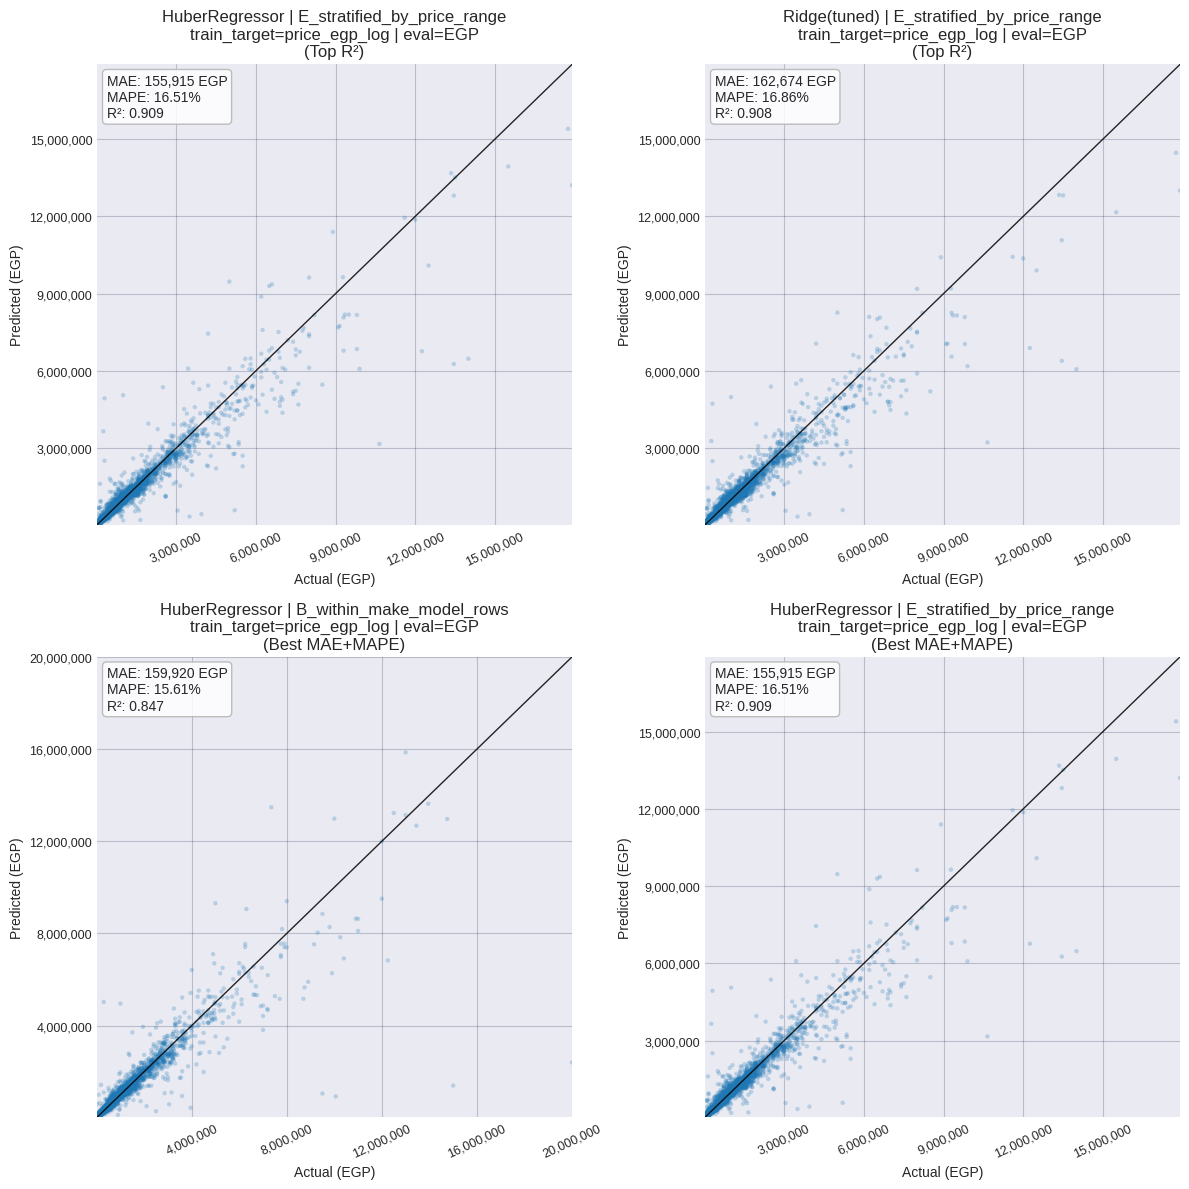

In [27]:
if len(results_by_target) == 0:
    raise RuntimeError("Run the benchmark cells first (price_egp / price_egp_log).")

# Ensure we have a combined table
results_all = pd.concat(list(results_by_target.values()), ignore_index=True, axis=0)
need_cols = {"train_target", "split", "model", "MAE", "MAPE_%", "R2"}
missing_cols = sorted(list(need_cols - set(results_all.columns)))
if missing_cols:
    raise RuntimeError(f"results_all missing columns: {missing_cols}")

cand = results_all.dropna(subset=["MAE", "MAPE_%", "R2"]).copy()
cand = cand.reset_index(drop=True)

def _model_to_pred_key(model_name: str) -> str:
    if model_name == "LinearRegression":
        return "preds_linear_eval"
    if model_name == "Ridge(tuned)":
        return "preds_ridge_eval"
    if model_name == "HuberRegressor":
        return "preds_huber_eval"
    raise KeyError(f"Unknown model name: {model_name}")

def _plot_pred_vs_true(ax, *, train_target: str, split_key: str, model_name: str, metrics_row: dict):
    store = pred_store_by_target[train_target][split_key]
    y_true = store["y_true_eval"]
    y_pred = store[_model_to_pred_key(model_name)]

    ax.scatter(y_true, y_pred, s=10, alpha=0.25, edgecolors="none", rasterized=True)

    lo = float(np.min([np.min(y_true), np.min(y_pred)]))
    hi = float(np.max([np.max(y_true), np.max(y_pred)]))
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1, alpha=0.85)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.tick_params(axis="x", labelrotation=25, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

    title = f"{model_name} | {split_key}\ntrain_target={train_target} | eval=EGP"
    ax.set_title(title)
    ax.set_xlabel("Actual (EGP)")
    ax.set_ylabel("Predicted (EGP)")
    ax.grid(True, alpha=0.25, color = "#2A3459")

    mae = float(metrics_row.get("MAE", np.nan))
    mape = float(metrics_row.get("MAPE_%", np.nan))
    r2 = float(metrics_row.get("R2", np.nan))
    txt = f"MAE: {mae:,.0f} EGP\nMAPE: {mape:.2f}%\nR²: {r2:.3f}"
    ax.text(
        0.02, 0.98, txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

# 1) Top-2 by R² (highest)
top_r2 = cand.sort_values(["R2", "MAE"], ascending=[False, True]).head(2)

# 2) Top-2 by (MAE + MAPE) combined rank (lowest)
cand["_rank_mae"] = cand["MAE"].rank(method="dense", ascending=True)
cand["_rank_mape"] = cand["MAPE_%"].rank(method="dense", ascending=True)
cand["_rank_score"] = (2.0 * cand["_rank_mae"] + 1.0 * cand["_rank_mape"])
top_err = cand.sort_values(["_rank_score", "MAE", "MAPE_%"], ascending=[True, True, True]).head(2)

print("Top 2 by R2:")
display(top_r2[["train_target", "split", "model", "MAE", "MAPE_%", "R2"]].reset_index(drop=True))
print("\nTop 2 by lowest MAE+MAPE (rank score):")
display(top_err[["train_target", "split", "model", "MAE", "MAPE_%", "R2"]].reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for i, (_, row) in enumerate(top_r2.iterrows()):
    _plot_pred_vs_true(
        axes[i],
        train_target=row["train_target"],
        split_key=row["split"],
        model_name=row["model"],
        metrics_row=row.to_dict(),
    )
axes[0].set_title(axes[0].get_title() + "\n(Top R²)")
axes[1].set_title(axes[1].get_title() + "\n(Top R²)")

for j, (_, row) in enumerate(top_err.iterrows()):
    _plot_pred_vs_true(
        axes[2 + j],
        train_target=row["train_target"],
        split_key=row["split"],
        model_name=row["model"],
        metrics_row=row.to_dict(),
    )
axes[2].set_title(axes[2].get_title() + "\n(Best MAE+MAPE)")
axes[3].set_title(axes[3].get_title() + "\n(Best MAE+MAPE)")

plt.tight_layout()
plt.show()

## 5) Export the fitted preprocessor (joblib)
We fit the preprocessor on **train only** (no leakage), then save it.

In [28]:
SPLIT_TO_EXPORT = 'B_within_make_model_rows'  # choose: A_random_rows / B_within_make_model_rows / C_split_by_make_only

Xtr, Xte, ytr, yte = splits[SPLIT_TO_EXPORT]

preprocessor_fitted = preprocessor.fit(Xtr)

out_dir = ML_ROOT / 'models' / 'preprocessors'
out_dir.mkdir(parents=True, exist_ok=True)

# joblib uses pickle under the hood; .pkl extension is fine
out_path = out_dir / 'linear_regression_preprocessor.pkl'
joblib.dump(preprocessor_fitted, out_path)

print('Saved preprocessor to:', out_path)
print('Export split:', SPLIT_TO_EXPORT)
print('Categorical:', len(categorical_cols), ' Numeric:', len(numeric_cols))

Saved preprocessor to: /home/mo-seif/Documents/GP/ml-service/models/preprocessors/linear_regression_preprocessor.pkl
Export split: B_within_make_model_rows
Categorical: 9  Numeric: 7


In [29]:
# Quick check: load it back and transform a small batch
loaded = joblib.load(out_path)
Xt = loaded.transform(X_all.iloc[:5])
print('Transformed shape (5 rows):', Xt.shape)

Transformed shape (5 rows): (5, 648)
